In [37]:
pip install opencv-contrib-python scikit-image pywavelets matplotlib pandas scikit-learn

In [38]:
import cv2
import os
import numpy as np
import pywt
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.decomposition import PCA
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
!ls "/content/drive/MyDrive/DIP Dataset 1 FEI"

originalimages_part1  originalimages_part3
originalimages_part2  originalimages_part4


In [41]:
import cv2
import os
import numpy as np

dataset_path = "/content/drive/MyDrive/DIP Dataset 1 FEI"

images = []
labels = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if not os.path.isdir(folder_path):
        continue

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        gray = cv2.resize(gray, (100,100))

        label = int(img_name.split("-")[0])

        images.append(gray)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Total images loaded:", len(images))
print("Total labels:", len(labels))

Total images loaded: 2800
Total labels: 2800


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.5,
    stratify=labels,
    random_state=42
)

In [43]:
def compute_metrics(preds):

    acc = accuracy_score(y_test,preds)*100
    prec = precision_score(y_test,preds,average='macro')*100
    rec = recall_score(y_test,preds,average='macro')*100
    f1 = f1_score(y_test,preds,average='macro')*100

    return acc,prec,rec,f1

In [44]:
def image_quality(original, processed):

    original = original.astype(np.uint8)
    processed = processed.astype(np.uint8)

    p = psnr(original, processed, data_range=255)

    s, _ = ssim(original, processed, full=True, data_range=255)

    return p, s

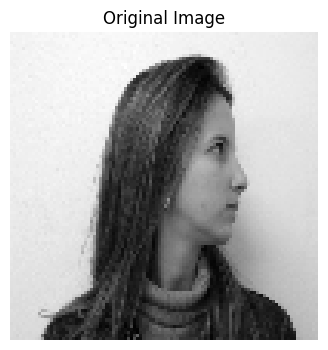

In [45]:
import matplotlib.pyplot as plt

sample = images[0]

plt.figure(figsize=(4,4))
plt.imshow(sample, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [46]:
def median_filter(img):
    return cv2.medianBlur(img,3)

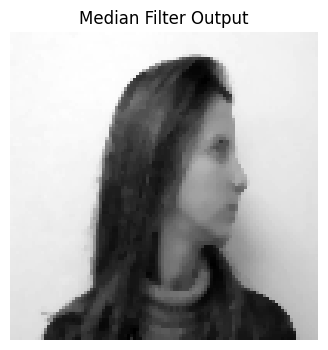

In [47]:
median_img = median_filter(sample)

plt.figure(figsize=(4,4))
plt.imshow(median_img, cmap='gray')
plt.title("Median Filter Output")
plt.axis("off")
plt.show()

In [48]:
def gray_normalization(img):

    norm = cv2.normalize(img,None,0,255,cv2.NORM_MINMAX)

    return norm

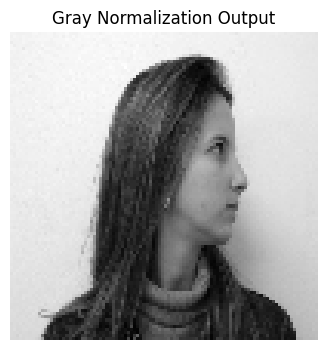

In [49]:
graynorm_img = gray_normalization(sample)

plt.figure(figsize=(4,4))
plt.imshow(graynorm_img, cmap='gray')
plt.title("Gray Normalization Output")
plt.axis("off")
plt.show()

In [50]:
def geometric_norm(img):

    rows,cols = img.shape

    M = cv2.getRotationMatrix2D((cols/2,rows/2),5,1)

    return cv2.warpAffine(img,M,(cols,rows))

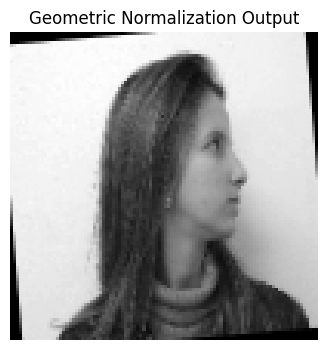

In [51]:
geom_img = geometric_norm(sample)

plt.figure(figsize=(4,4))
plt.imshow(geom_img, cmap='gray')
plt.title("Geometric Normalization Output")
plt.axis("off")
plt.show()

In [52]:
def wavelet_transform(img):

    coeffs = pywt.dwt2(img,'haar')

    LL,(LH,HL,HH) = coeffs

    return cv2.resize(LL,(100,100))

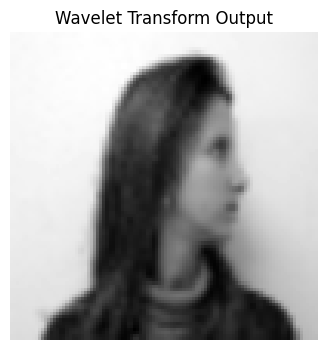

In [53]:
wavelet_img = wavelet_transform(sample)

plt.figure(figsize=(4,4))
plt.imshow(wavelet_img, cmap='gray')
plt.title("Wavelet Transform Output")
plt.axis("off")
plt.show()

In [54]:
def hist_eq(img):

    return cv2.equalizeHist(img)

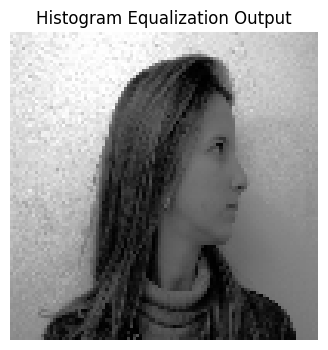

In [55]:
hist_img = hist_eq(sample)

plt.figure(figsize=(4,4))
plt.imshow(hist_img, cmap='gray')
plt.title("Histogram Equalization Output")
plt.axis("off")
plt.show()

In [56]:
methods = {
"Original":lambda x:x,
"Median":median_filter,
"GrayNorm":gray_normalization,
"Geometric":geometric_norm,
"Wavelet":wavelet_transform,
"Histogram":hist_eq,
}

results=[]
accuracies=[]

In [57]:
def flatten_images(images):

    flattened = []

    for img in images:
        flattened.append(img.flatten())

    return np.array(flattened)

In [58]:
results = []

for name, func in methods.items():

    # Apply preprocessing
    X_train_proc = np.array([func(img) for img in X_train])
    X_test_proc = np.array([func(img) for img in X_test])

    # Flatten images
    X_train_flat = flatten_images(X_train_proc)
    X_test_flat = flatten_images(X_test_proc)

    # PCA feature extraction
    pca = PCA(n_components=100)

    X_train_pca = pca.fit_transform(X_train_flat)
    X_test_pca = pca.transform(X_test_flat)

    # Train classifier
    model = SVC(kernel='linear')

    model.fit(X_train_pca, y_train)

    preds = model.predict(X_test_pca)

    # Compute recognition metrics
    acc, prec, rec, f1 = compute_metrics(preds)

    # Compute image quality metrics
    psnr_values = []
    ssim_values = []

    for i in range(len(X_test)):
        p, s = image_quality(X_test[i], X_test_proc[i])
        psnr_values.append(p)
        ssim_values.append(s)

    psnr_avg = np.mean(psnr_values)
    ssim_avg = np.mean(ssim_values)

    # Store results
    results.append([name, acc, prec, rec, f1, psnr_avg, ssim_avg])

    # Print results
    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("PSNR:", psnr_avg)
    print("SSIM:", ssim_avg)
    print("---------------------")

/usr/local/lib/python3.12/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


Original
Accuracy: 80.35714285714286
Precision: 82.87917637917639
Recall: 80.35714285714286
F1 Score: 80.09294853753059
PSNR: inf
SSIM: 1.0
---------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Median
Accuracy: 80.35714285714286
Precision: 83.12932345432345
Recall: 80.35714285714286
F1 Score: 80.04048252658933
PSNR: 35.069953128711205
SSIM: 0.9572279725807556
---------------------
GrayNorm
Accuracy: 87.85714285714286
Precision: 90.448079004329
Recall: 87.85714285714286
F1 Score: 87.68508490376676
PSNR: 15.754723904586346
SSIM: 0.9159372455648728
---------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Geometric
Accuracy: 80.64285714285714
Precision: 83.35728715728715
Recall: 80.64285714285714
F1 Score: 80.44029929478847
PSNR: 16.902160161060127
SSIM: 0.7206743406347812
---------------------
Wavelet
Accuracy: 81.64285714285714
Precision: 84.2423187923188
Recall: 81.64285714285714
F1 Score: 81.48310243248324
PSNR: 10.617560161721379
SSIM: 0.5536962759209756
---------------------
Histogram
Accuracy: 87.28571428571429
Precision: 88.86875901875902
Recall: 87.28571428571428
F1 Score: 86.99522503640152
PSNR: 17.96286940070622
SSIM: 0.751586270131687
---------------------


In [59]:
columns = ["Method","Accuracy","Precision","Recall","F1 Score","PSNR","SSIM"]

df = pd.DataFrame(results,columns=columns)

print(df)

      Method   Accuracy  Precision     Recall   F1 Score       PSNR      SSIM
0   Original  80.357143  82.879176  80.357143  80.092949        inf  1.000000
1     Median  80.357143  83.129323  80.357143  80.040483  35.069953  0.957228
2   GrayNorm  87.857143  90.448079  87.857143  87.685085  15.754724  0.915937
3  Geometric  80.642857  83.357287  80.642857  80.440299  16.902160  0.720674
4    Wavelet  81.642857  84.242319  81.642857  81.483102  10.617560  0.553696
5  Histogram  87.285714  88.868759  87.285714  86.995225  17.962869  0.751586


In [60]:
display(df)

,Method,Accuracy,Precision,Recall,F1 Score,PSNR,SSIM
0,Original,80.357143,82.879176,80.357143,80.092949,inf,1.000000
1,Median,80.357143,83.129323,80.357143,80.040483,35.069953,0.957228
2,GrayNorm,87.857143,90.448079,87.857143,87.685085,15.754724,0.915937
3,Geometric,80.642857,83.357287,80.642857,80.440299,16.902160,0.720674
4,Wavelet,81.642857,84.242319,81.642857,81.483102,10.617560,0.553696
5,Histogram,87.285714,88.868759,87.285714,86.995225,17.962869,0.751586


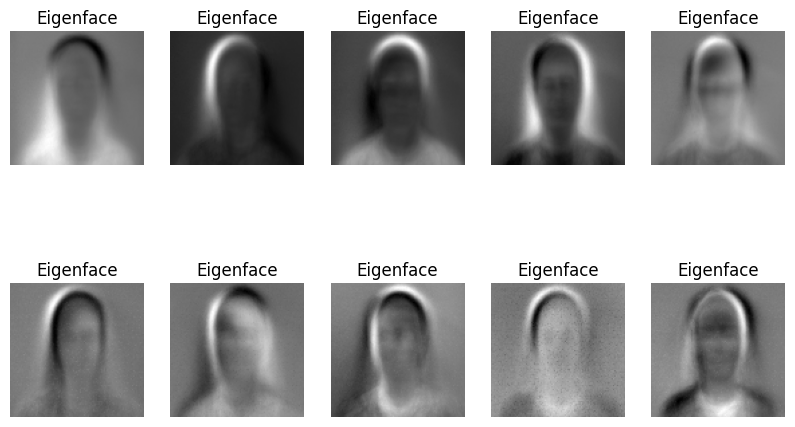

In [61]:
eigenfaces = pca.components_.reshape((100,100,100))

plt.figure(figsize=(10,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(eigenfaces[i], cmap='gray')
    plt.title("Eigenface")
    plt.axis('off')

plt.show()

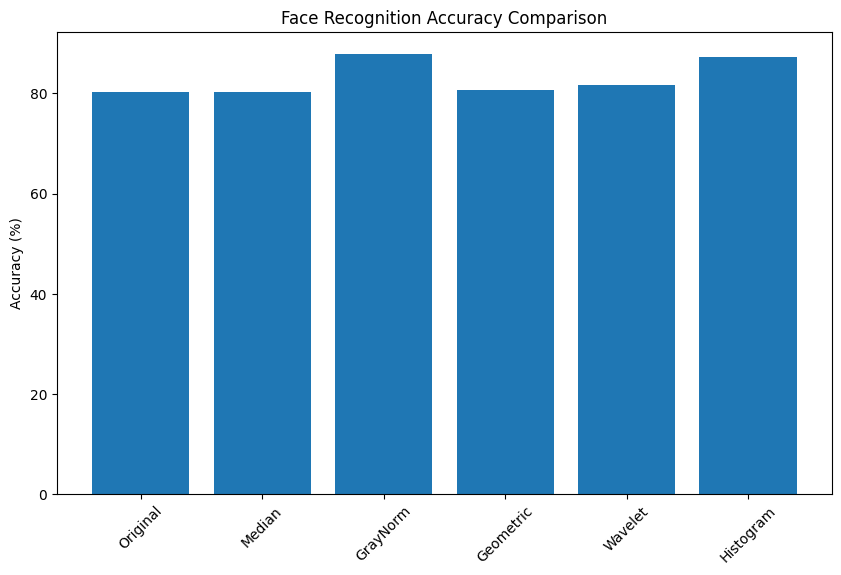

In [62]:
methods_list = [r[0] for r in results]
accuracies = [r[1] for r in results]

plt.figure(figsize=(10,6))
plt.bar(methods_list, accuracies)
plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Face Recognition Accuracy Comparison")
plt.show()

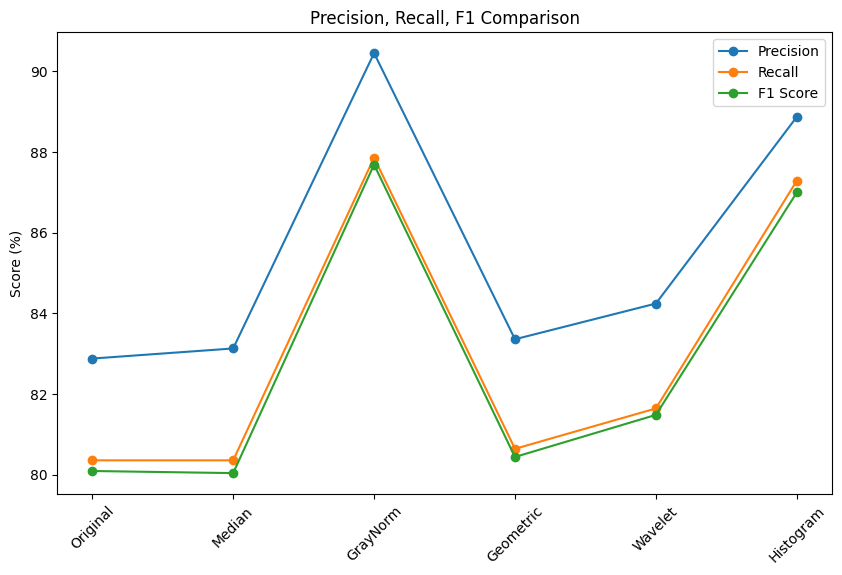

In [63]:
plt.figure(figsize=(10,6))

plt.plot(df["Method"], df["Precision"], marker='o', label="Precision")
plt.plot(df["Method"], df["Recall"], marker='o', label="Recall")
plt.plot(df["Method"], df["F1 Score"], marker='o', label="F1 Score")

plt.xticks(rotation=45)

plt.ylabel("Score (%)")
plt.title("Precision, Recall, F1 Comparison")

plt.legend()

plt.show()

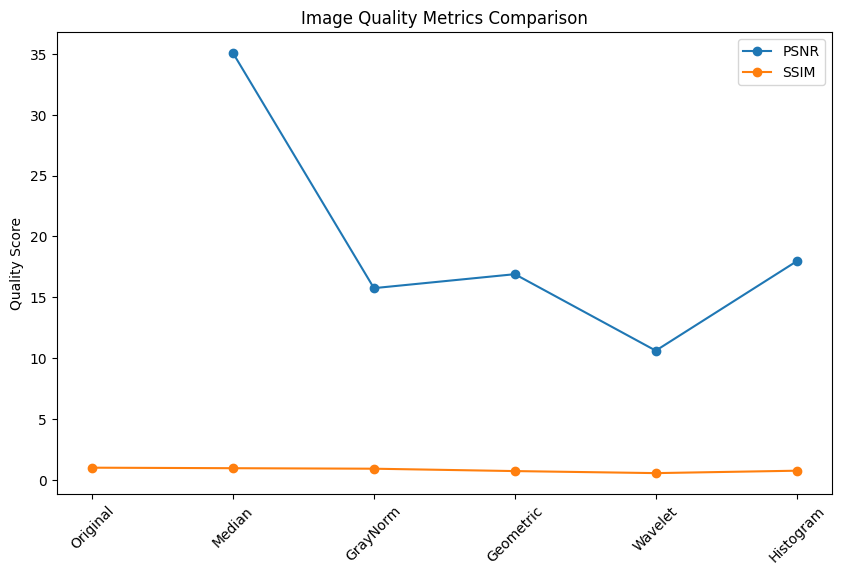

In [64]:
plt.figure(figsize=(10,6))

plt.plot(df["Method"], df["PSNR"], marker='o', label="PSNR")
plt.plot(df["Method"], df["SSIM"], marker='o', label="SSIM")

plt.xticks(rotation=45)

plt.ylabel("Quality Score")
plt.title("Image Quality Metrics Comparison")

plt.legend()

plt.show()

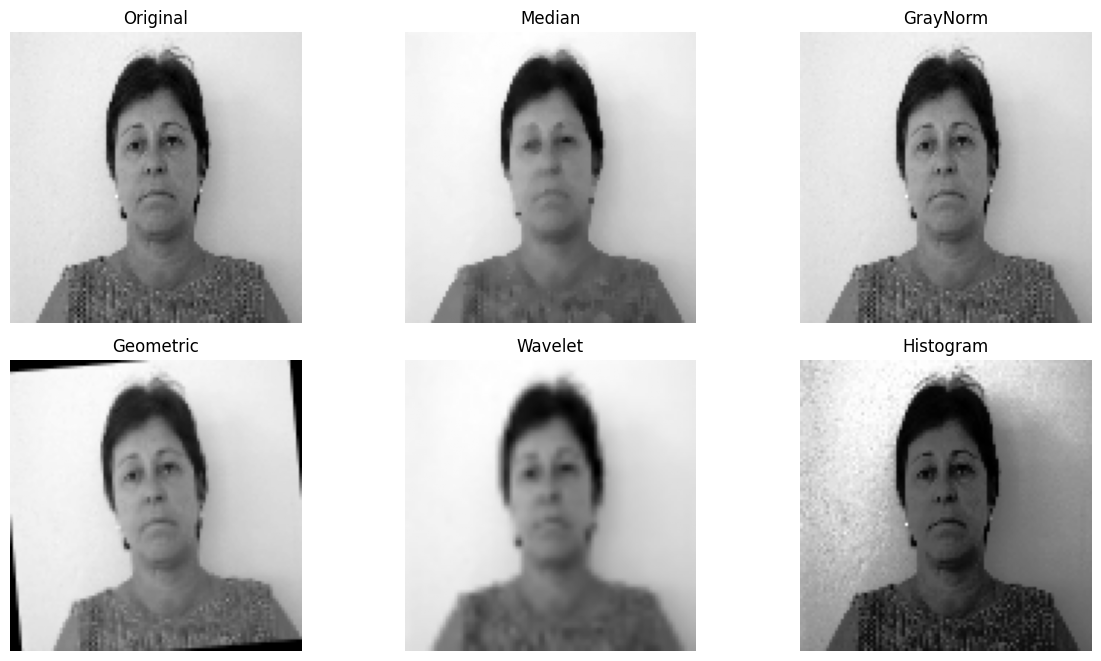

In [65]:
import matplotlib.pyplot as plt

sample = X_test[0]

plt.figure(figsize=(12,10))

# show original
plt.subplot(3,3,1)
plt.imshow(sample, cmap='gray')
plt.title("Original")
plt.axis("off")

i = 2

for name, func in methods.items():

    if name == "Original":
        continue

    processed = func(sample)

    plt.subplot(3,3,i)
    plt.imshow(processed, cmap='gray')
    plt.title(name)
    plt.axis("off")

    i += 1

plt.tight_layout()
plt.show()